<a href="https://colab.research.google.com/github/Devv07/ai-ml-practice/blob/ai-ml-practice/ACO_and_PSO_Optimization_Algorithms_with_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Ant Colony Optimization (ACO)**
1. Ant Leave the pheromones(chemical) on the path
2. Other ant follows stronger pheromones paths
3 .Shorter path =more pheromones quuckly=more ants follows it
4. Best paths win

**Stigmergy**
1. Indirect communication through environment
2. Ant don't talk they use pheromones trails

**Working **


*   Many artifical ants start from random points
*   Each ant moves randomly at first
*   Ant choose next path based on pheromones strength
*   After reacing  destination  -updates pheromones
*   Evaporation :Old pheromones fades
*   After many iterations - shortest.best path remains

**Key Points**
* Pheromone evaporation rate (p):
* Small p = slow change
* Large p = fast change
* Best for : Path Problems,Routing,Scheduling
* Example :Travelling Salesman Problem(TSP) : Find shortest city tour.

                ** Ants + Pheromones + Shortest Path = ACO **





In [9]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np

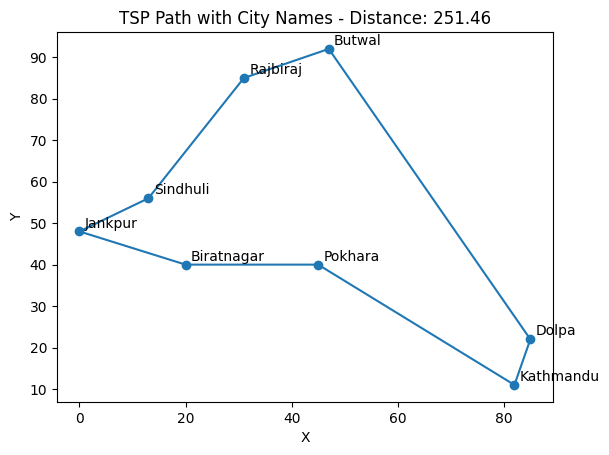

Best Path: [1, 6, 4, 2, 3, 0, 5, 7]
Distance: 251.4629646314603


In [5]:
city_names = ["Kathmandu","Rajbiraj","Biratnagar","Pokhara","Jankpur","Dolpa","Sindhuli","Butwal"]

def distance(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])

def path_length(path, cities):
    return sum(distance(cities[path[i]], cities[path[(i + 1) % len(path)]]) for i in range(len(path)))

def tsp(cities, iterations=5000):
    n = len(cities)
    best_path = list(range(n))
    random.shuffle(best_path)
    best_length = path_length(best_path, cities)

    for _ in range(iterations):
        new_path = best_path[:]
        i, j = random.sample(range(n), 2)
        new_path[i], new_path[j] = new_path[j], new_path[i]
        new_length = path_length(new_path, cities)

        if new_length < best_length:
            best_path, best_length = new_path, new_length

    return best_path, best_length

cities = [(random.randint(0, 100), random.randint(0, 100)) for _ in range(8)]
path, length = tsp(cities)

x = [cities[i][0] for i in path] + [cities[path[0]][0]]
y = [cities[i][1] for i in path] + [cities[path[0]][1]]

plt.figure()
plt.scatter([c[0] for c in cities], [c[1] for c in cities])

for i, (x_city, y_city) in enumerate(cities):
    plt.text(x_city + 1, y_city + 1, city_names[i])

plt.plot(x, y)
plt.title(f"TSP Path with City Names - Distance: {length:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

print("Best Path:", path)
print("Distance:", length)

**Particle Swarm Optimization (PSO)**

Particle Swarm Optimization (PSO) is a population-based optimization algorithm inspired by the collective behavior of birds or fish.

Concept:
  * Each particle=one solution
  * Particle fly in search space
  * Learn From:

    Personal best(pbest)-its own experience

    Globle best(Gbest) -swarms best experience

Rules:
* Separation : Avoid collision
* Alignment : Move int the same direction
* Cohesion : Stay close to the group


Working:
* Initialize random particles
* Evaluate fitness(Solution Quality)
* Update:
  Personal Best
  Global Best
  * Update Position
  * Repeat until best solution until
Parameters:
 W(inertia) : Keep particle

🏗 Components of PSO

1️⃣ Particles – candidate solutions

2️⃣ Position – current solution

3️⃣ Velocity – direction & speed of movement

4️⃣ pBest – particle’s best position so far

5️⃣ gBest – global best position found by swarm



⚙️ How PSO Works (Step-by-Step)

* Initialize particles with random positions and velocities

* Evaluate fitness of each particle

* Update pBest and gBest

* Update velocity using:

   * inertia

  * cognitive component (self-learning)

  * social component (group-learning)

* Update particle position

* Repeat until stopping condition is met

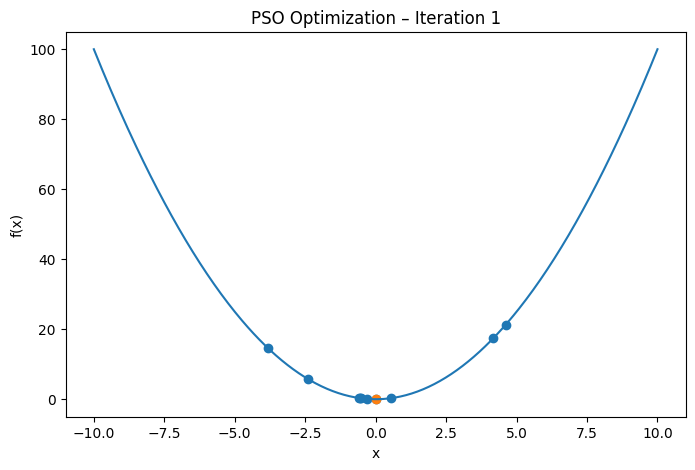

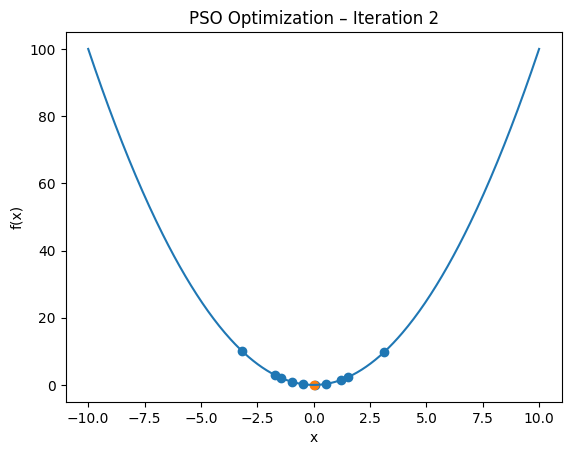

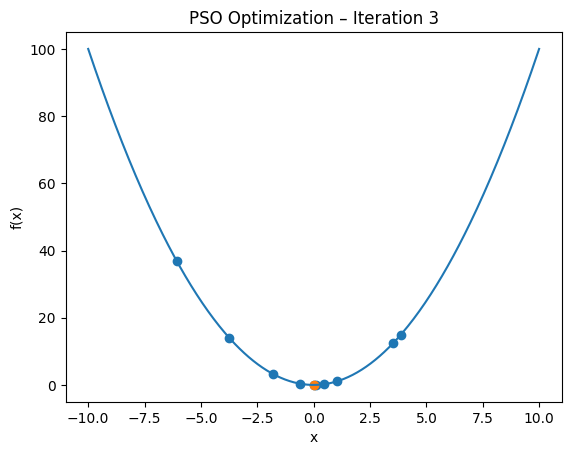

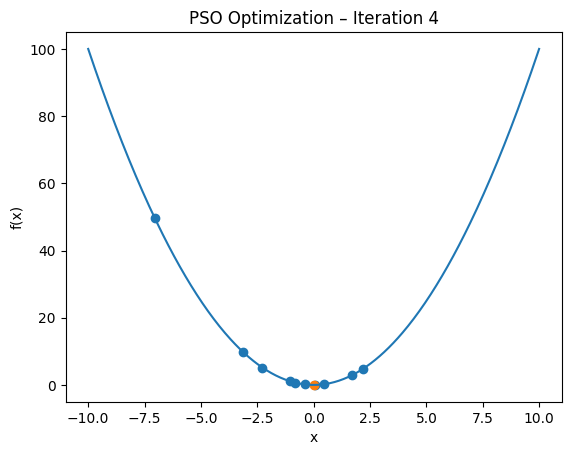

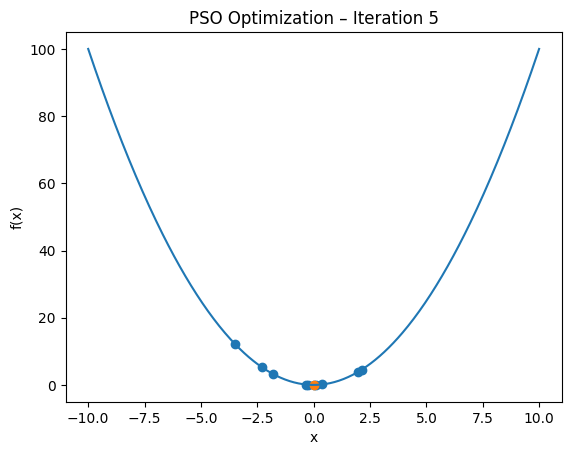

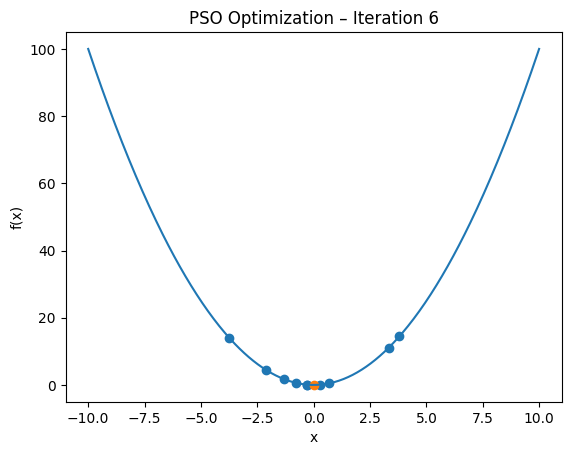

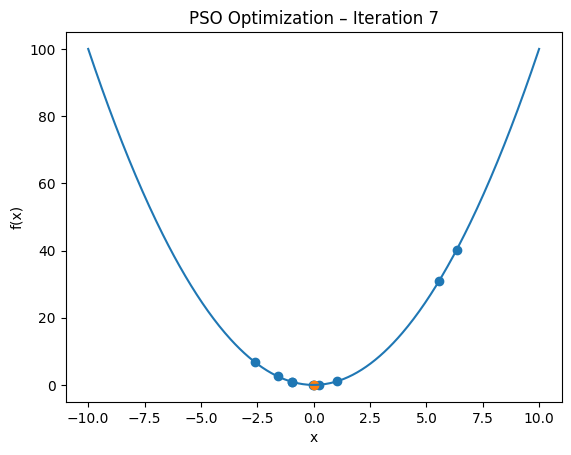

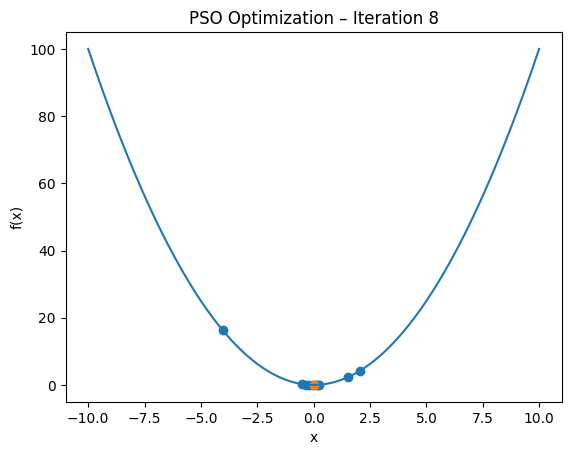

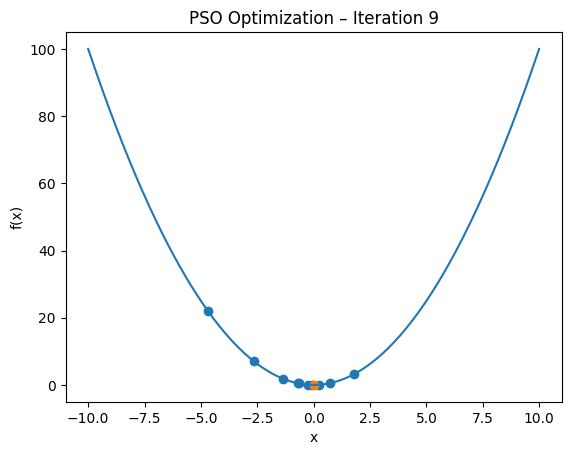

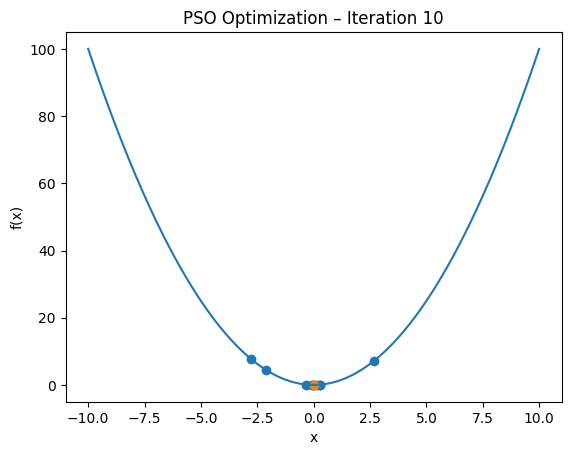

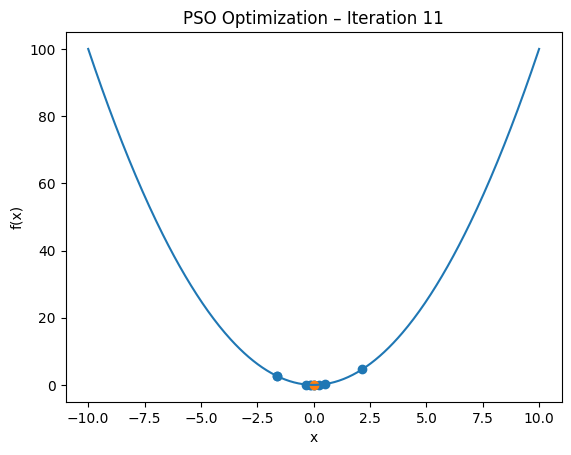

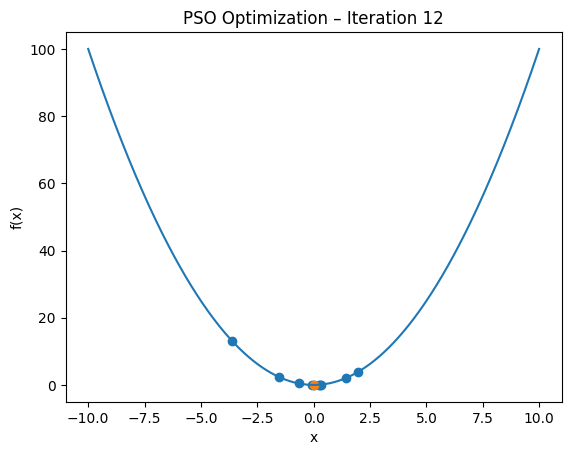

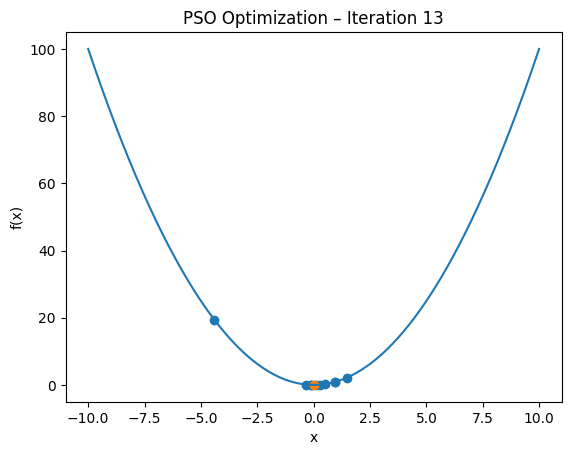

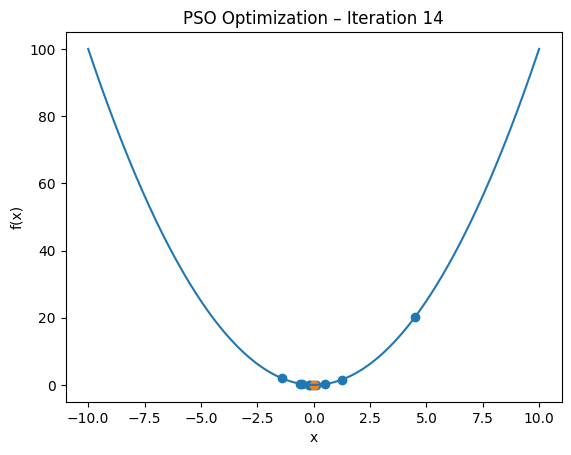

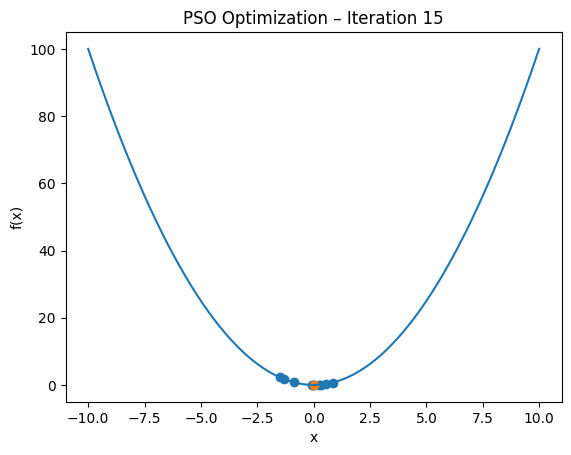

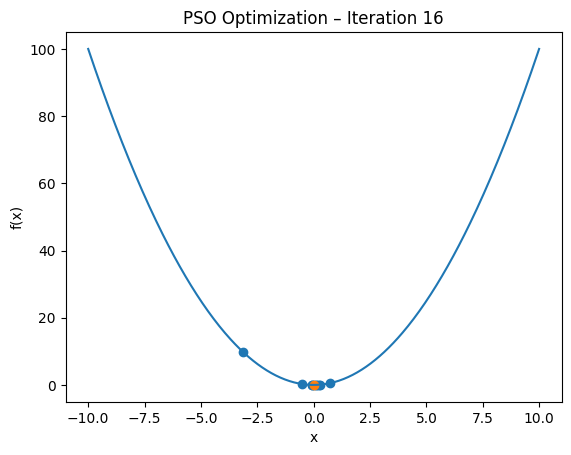

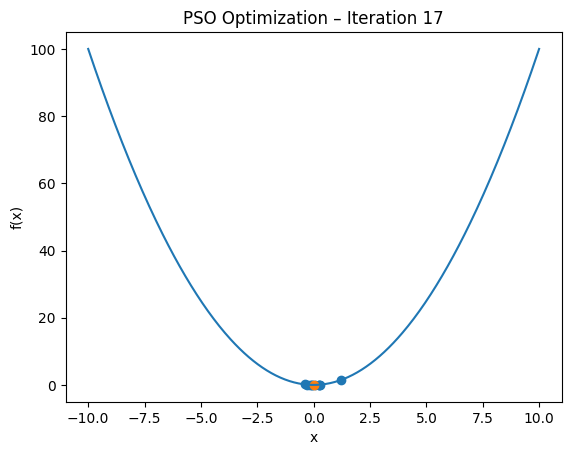

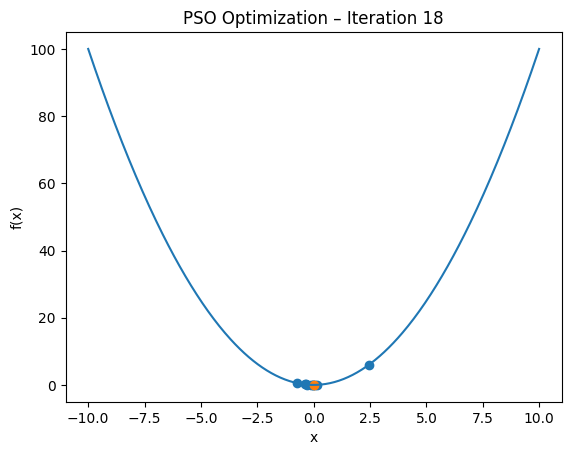

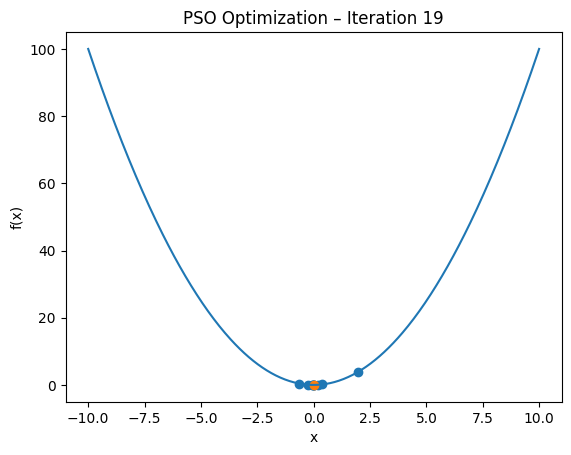

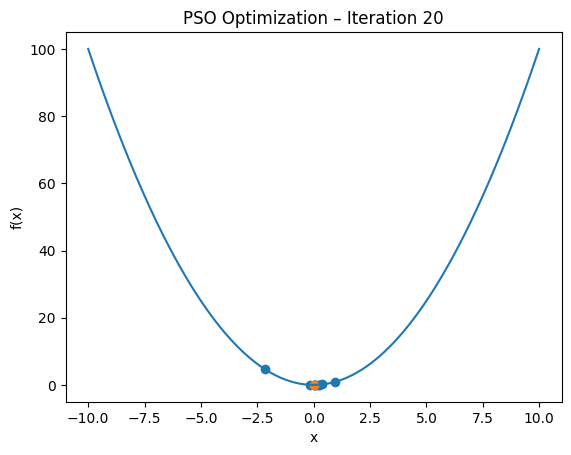

Global Best Position: 0.0009655743246310411
Global Best Value: 9.323337763866912e-07


In [10]:
# Objective function
def objective_function(x):
    return x ** 2

# PSO parameters
num_particles = 10
iterations = 20
w = 0.7      # inertia weight
c1 = 1.5     # cognitive coefficient
c2 = 1.5     # social coefficient

# Initialize particles
positions = np.random.uniform(-10, 10, num_particles)
velocities = np.random.uniform(-1, 1, num_particles)

personal_best_positions = positions.copy()
personal_best_scores = objective_function(positions)

global_best_position = personal_best_positions[
    np.argmin(personal_best_scores)
]

# Visualization setup
x = np.linspace(-10, 10, 400)
y = objective_function(x)

plt.figure(figsize=(8, 5))

for iteration in range(iterations):
    for i in range(num_particles):
        r1, r2 = np.random.rand(), np.random.rand()

        velocities[i] = (
            w * velocities[i]
            + c1 * r1 * (personal_best_positions[i] - positions[i])
            + c2 * r2 * (global_best_position - positions[i])
        )

        positions[i] += velocities[i]
        score = objective_function(positions[i])

        if score < personal_best_scores[i]:
            personal_best_scores[i] = score
            personal_best_positions[i] = positions[i]

    global_best_position = personal_best_positions[
        np.argmin(personal_best_scores)
    ]

    # Plot
    plt.clf()
    plt.plot(x, y)
    plt.scatter(positions, objective_function(positions))
    plt.scatter(global_best_position, objective_function(global_best_position))
    plt.title(f"PSO Optimization – Iteration {iteration + 1}")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.pause(0.3)

plt.show()

print("Global Best Position:", global_best_position)
print("Global Best Value:", objective_function(global_best_position))


In [7]:
import random

def fitness(x):
    return x**2 + 4*x + 4

n = 5
positions = [random.uniform(-10, 10) for _ in range(n)]
velocities = [0]*n
pbest = positions[:]
gbest = min(pbest, key=fitness)

w, c1, c2 = 0.5, 1.5, 1.5

for _ in range(20):
    for i in range(n):
        r1, r2 = random.random(), random.random()
        velocities[i] = (w*velocities[i] +
                         c1*r1*(pbest[i]-positions[i]) +
                         c2*r2*(gbest-positions[i]))
        positions[i] += velocities[i]

        if fitness(positions[i]) < fitness(pbest[i]):
            pbest[i] = positions[i]

    gbest = min(pbest, key=fitness)

print("Best Value:", gbest)
print("Minimum Fitness:", fitness(gbest))

Best Value: -2.0003448132588546
Minimum Fitness: 1.1889618356519804e-07


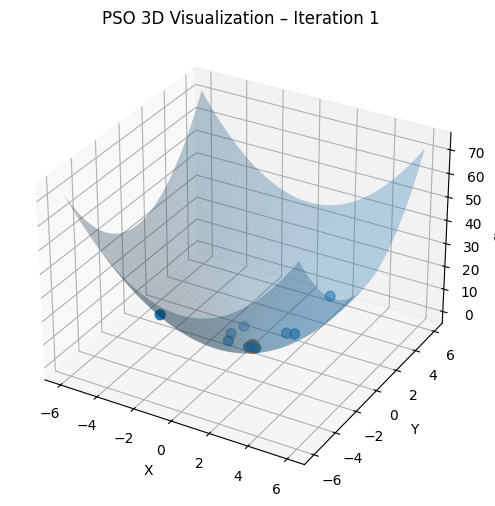

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def fitness(pos):
    return pos[0]**2 + pos[1]**2

num_particles = 10
iterations = 25
w, c1, c2 = 0.6, 1.4, 1.4

positions = np.random.uniform(-6, 6, (num_particles, 2))
velocities = np.random.uniform(-1, 1, (num_particles, 2))

pbest = positions.copy()
pbest_scores = np.array([fitness(p) for p in positions])
gbest = pbest[np.argmin(pbest_scores)]

# Surface
x = np.linspace(-6, 6, 50)
y = np.linspace(-6, 6, 50)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

for it in range(iterations):
    for i in range(num_particles):
        r1, r2 = np.random.rand(), np.random.rand()
        velocities[i] = (
            w * velocities[i]
            + c1 * r1 * (pbest[i] - positions[i])
            + c2 * r2 * (gbest - positions[i])
        )
        positions[i] += velocities[i]

        score = fitness(positions[i])
        if score < pbest_scores[i]:
            pbest_scores[i] = score
            pbest[i] = positions[i]

    gbest = pbest[np.argmin(pbest_scores)]

    ax.clear()
    ax.plot_surface(X, Y, Z, alpha=0.3)
    ax.scatter(
        positions[:, 0],
        positions[:, 1],
        [fitness(p) for p in positions],
        s=50
    )
    ax.scatter(gbest[0], gbest[1], fitness(gbest), s=100)
    ax.set_title(f"PSO 3D Visualization – Iteration {it+1}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("f(x,y)")
    plt.pause(0.4)

plt.show()
